### [주제 : 붓꽃(iris)의 품종 분류] <hr>
- 학습 종류 : 지도학습 - 분류
- 구현 단계
    * (1) 데이터 준비 및 확인
    * (2) 데이터 전처리
    * (3) 학습용|검증용|테스트용 데이터셋 준비
    * (4) 학습
    * (5) 평가

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import koreanlize_matplotlib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate

from sklearn.neighbors import KNeighborsClassifier


**[1] 데이터 준비 및 확인**

In [4]:
## 데이터 선정
DATA_FILE = '../Data/Numbers/iris.csv'
dataDF = pd.read_csv(DATA_FILE)

In [9]:
dataDF.info()
display(dataDF.head(3))
display(dataDF.describe(include='all'))

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa


,sepal.length,sepal.width,petal.length,petal.width,variety
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


In [10]:
# [1차 해석]
# - variety 컬럼 : str => category 형변환
# - 결측치 : 없음
# 

**[2] 데이터 전처리**

In [20]:
# variety 컬럼 : str => category 형변환
dataDF['variety'] = dataDF['variety'].astype('category')
dataDF.dtypes

sepal.length     float64
sepal.width      float64
petal.length     float64
petal.width      float64
variety         category
dtype: object

**[3] 학습용|검증용|테스트용 데이터셋 준비**

In [22]:
## 피처와 타겟 분리
featureDF = dataDF[dataDF.columns[:-1]]
target = dataDF[dataDF.columns[-1]]
print(featureDF.shape, target.shape)

(150, 4) (150,)


In [23]:
# 학습용|테스트용 분리 : 분류 => 타겟 쿨래스 비율 유지 stratify 매개변수 설정
#                     재현성 => random_state 매개변수 설정
#                     피쳐 차원 => 2D, 타겟 차원 => 1D
x_train, x_test, y_train, y_test  = train_test_split(featureDF, target, 
                 test_size=0.2, 
                 random_state=10, 
                 stratify=target)

In [26]:
print(f'{x_train.shape}, {y_train.shape}, {x_test.shape}, {y_test.shape}')
print(f'{y_train.value_counts().tolist()}')
print(f'{y_test.value_counts().tolist()}')

(120, 4), (120,), (30, 4), (30,)
[40, 40, 40]
[10, 10, 10]


**[4] 교차검증**

In [32]:
## => 모델 인스턴스, 학습용 데이터, 학습용 정답
# 모델 인스턴스 : KNN
k_model = KNeighborsClassifier()

# => cross_val_score 함수 : 교차검증 검증데이터 평가 점수
val_scores = cross_val_score(k_model, x_train, y_train)
print(f'검증 데이터 평가 점수 : {val_scores}, 평균 점수 : {val_scores.mean()}')

검증 데이터 평가 점수 : [0.95833333 0.875      0.91666667 1.         0.95833333], 평균 점수 : 0.9416666666666667


In [39]:
# => cross_validate 함수 : 교차검증 검증데이터 평가 점수
all_scores = cross_validate(k_model, x_train, y_train, return_train_score=True)

scoreDF = pd.DataFrame(all_scores)

scoreDF['GAP'] = abs(scoreDF['train_score'] - scoreDF['test_score'])
scoreDF.loc['AVG'] = [scoreDF[col].mean() for col in scoreDF.columns]

display(scoreDF)

print('[종합평기]')
print(f'{scoreDF.loc["AVG", "GAP"]:.4f}')

,fit_time,score_time,test_score,train_score,GAP
0,0.003054,0.003520,0.958333,0.979167,0.020833
1,0.002004,0.002507,0.875000,0.989583,0.114583
2,0.002279,0.002999,0.916667,0.979167,0.062500
3,0.002000,0.001533,1.000000,0.968750,0.031250
4,0.001010,0.001000,0.958333,0.979167,0.020833
AVG,0.002069,0.002312,0.941667,0.979167,0.050000


[종합평기]
0.0500


**[5] 성능 향상을 위한 K 찾기**
* 모델 성능에 영향을 미치는 파라미터 : 하이퍼파라미터(Hyper Parameter)
* 모델마다 개수도 다르고, 종류도 다름

In [ ]:
# => KNN : K - 모델 성능 좌우
# K값을 변경하면서 평균 모델 성능 체크
# K값 범위 : 1 ~ 전체데이터수-1 / 홀수 사용
totalDict = {'K':[], 'train_score': [], 'test_score': []}
for k in range(1, 50, 2):
    k_model = KNeighborsClassifier(n_neighbors=k)

    # => 교차검증
    resDict = cross_validate(k_model, x_train, y_train, return_train_score=True)

    # => 학습점수, 검증 점수
    # print(resDict['train_score'].mean(), resDict['test_score'].mean())
    totalDict['K'].append(k)
    totalDict['train_score'].append(resDict['train_score'].mean().round(5))
    totalDict['test_score'].append(resDict['test_score'].mean().round(5))

In [73]:
# K값에 따른 성능 비교
totalDF = pd.DataFrame(totalDict)

# 학습 - 검증 차이가 가장 작은 K
totalDF['Abs_Gap'] = abs(totalDF['train_score'] - totalDF['test_score'])
sortDF = totalDF.sort_values(by=['test_score', 'Abs_Gap'], ascending=[False,True], ignore_index=True)

# 최고 성능 K, 최고 점수
best_k, best_score = sortDF.iloc[0]['K'], sortDF.iloc[0]['test_score']
min_y, max_y = totalDF['train_score'].min(), totalDF['train_score'].max()

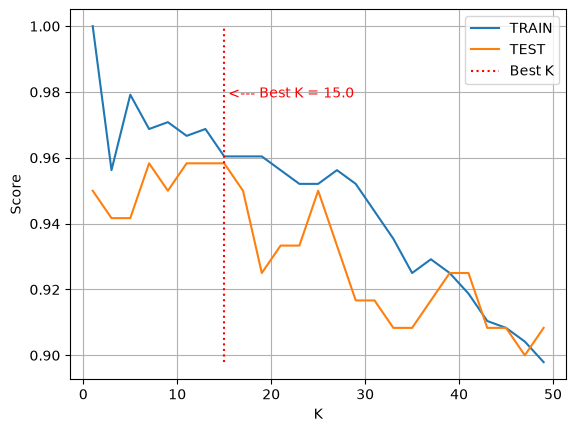

In [74]:
# 학습 점수, 검증 점수 그래프
plt.plot(totalDF['K'], totalDF['train_score'], label = ['TRAIN'])
plt.plot(totalDF['K'], totalDF['test_score'], label = ['TEST'])

# 베스트 K
plt.vlines(best_k, min_y, max_y, colors='red', linestyles='dotted', label='Best K')
plt.text(best_k, best_score+0.02, f' <--- Best K = {best_k}', c = 'red')

# 그래프
plt.legend()
plt.xlabel('K')
plt.ylabel('Score')
plt.grid()
plt.show()

**[6] 테스트 데이터 예측**

In [87]:
# 테스트 데이터 셋으로 예측 및 평가
k_model = KNeighborsClassifier(n_neighbors=15)
k_model.fit(x_train, y_train)

# 예측진행
y_pre = k_model.predict(x_test)

# 정답과 예측 진행 : 정답과 오답 개수
correct = (y_pre == y_test).sum()
incorrect = y_pre.shape[0] - correct
print(f'[테스트 예측 평가] 정답 개수 : {correct}개, 오답 개수 : {incorrect}개')

[테스트 예측 평가] 정답 개수 : 30개, 오답 개수 : 0개
